<img align="right" style="padding-left:50px;" src="figures_wk4/data_cleaning.png" width=350><br>
### User Bias in Data Cleaning
For your homework assignment this week, we will explore how our treatment of our data can impact the quality of our results.

**Dataset:**
The data is a Salary Survey from AskAManager.org. It’s US-centric-ish but does allow for a range of country inputs.

A list of the corresponding survey questions can be found [here](https://www.askamanager.org/2021/04/how-much-money-do-you-make-4.html).

 

In [55]:
import pandas as pd

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df= pd.read_csv('survey_data.csv')

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28108 entries, 0 to 28107
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  28108 non-null  object 
 1   q1         28108 non-null  object 
 2   q2         28033 non-null  object 
 3   q3         28107 non-null  object 
 4   q4         7273 non-null   object 
 5   q5         28108 non-null  object 
 6   q6         20793 non-null  float64
 7   q7         28108 non-null  object 
 8   q8         211 non-null    object 
 9   q9         3047 non-null   object 
 10  q10        28108 non-null  object 
 11  q11        23074 non-null  object 
 12  q12        28026 non-null  object 
 13  q13        28108 non-null  object 
 14  q14        28108 non-null  object 
 15  q15        27885 non-null  object 
 16  q16        27937 non-null  object 
 17  q17        27931 non-null  object 
dtypes: float64(1), object(17)
memory usage: 3.9+ MB


In [59]:
df.head()

,timestamp,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16,q17
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


### Assignment
Your goal for this assignment is to observe how your data treatment during the cleaning process can skew or bias the dataset.

Before diving right in, stop and read through the questions associated with the dataset. As you can see, they are either free-form text entries or categorical selections. Knowing this, perform some exploratory data analysis (EDA) to investigate the "state" of the dataset.

[Add as many code cell below here as needs]


first, i will just run a quick value count for few columns for my analysis. 

In [60]:
# Counting occurrences of each gender
gender_counts = df['q16'].value_counts()
print(gender_counts)

q16
Woman                            21389
Man                               5502
Non-binary                         747
Other or prefer not to answer      298
Prefer not to answer                 1
Name: count, dtype: int64


In [61]:
# Counting occurrences of each industry
industry_counts = df['q2'].value_counts()
print(industry_counts)


q2
Computing or Tech                          4711
Education (Higher Education)               2466
Nonprofits                                 2420
Health care                                1899
Government and Public Administration       1893
                                           ... 
Gaming (Gambling)                             1
Regulatory Affairs- nutraceuticals            1
Manufacturing : corporate admin support       1
Real Estate Investment Support                1
Social networks                               1
Name: count, Length: 1220, dtype: int64


In [62]:
# Counting occurrences of each racial group
race_counts = df['q17'].value_counts()
print(race_counts)

q17
White                                                                                                                                                                                                                           23235
Asian or Asian American                                                                                                                                                                                                          1410
Black or African American                                                                                                                                                                                                         694
Another option not listed here or prefer not to answer                                                                                                                                                                            625
Hispanic, Latino, or Spanish origin                                         

/var/folders/gr/jbd0vdz11hs7pfwtxs9llsv40000gn/T/ipykernel_65075/2706014479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


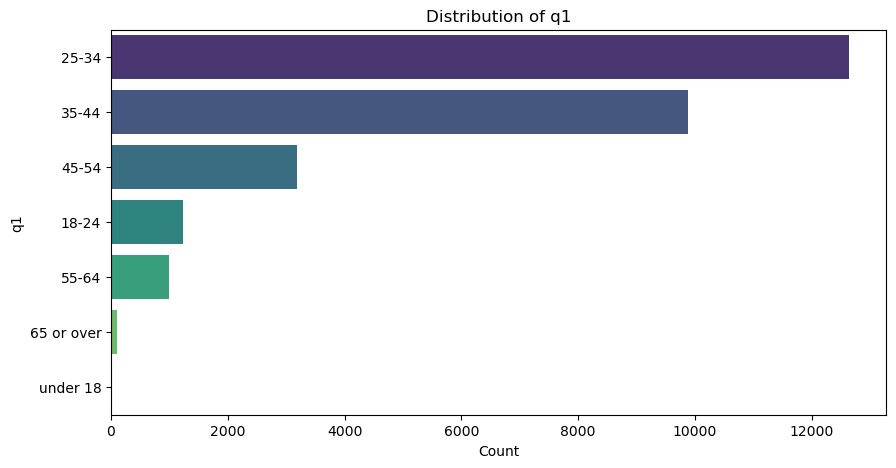

/var/folders/gr/jbd0vdz11hs7pfwtxs9llsv40000gn/T/ipykernel_65075/2706014479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


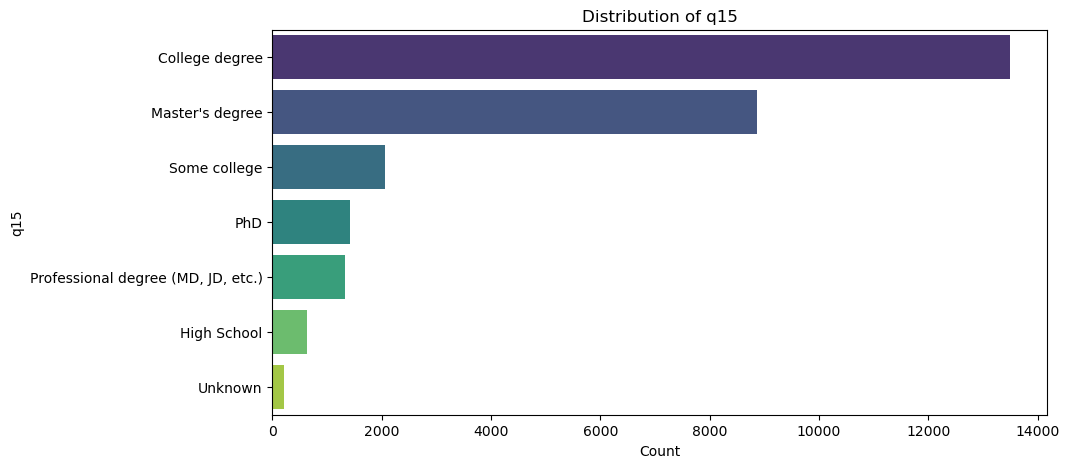

In [70]:
# (EDA)
columns_to_analyze = ['q1', 'q15']
for col in columns_to_analyze:
    plt.figure(figsize=(10, 5))
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

**Question:** How would you describe the "state" of this dataset? Be specific and detailed in your answer. (Think paragraphs rather than sentences).

[Add you answer to this markdown cell]

1. Completeness of Data and Missing Values
There are missing values in a sizable percentage of the dataset, and several columns are incomplete. The most concerning are q 8 and 9, which are almost useless because of how few the responses are. Other variables, such q4 and q6, present difficulties as well, especially if they include important information. When missing values are present, we must either impute missing data or remove useless columns before conducting any meaningful analysis.

2. Standardization and Consistency of Data
The dataset has labeling problems and uneven formatting, especially in categorical columns like q10 (country). There are several versions of the same nation name (such as "US," "USA," and "United States"), which, if not standardized, may lead to errors. Likewise, industries (q2) and job titles (q3) could contain overlapping but inconsistently recorded categories that need to be normalized to guarantee comparability. Reducing redundancy and enhancing data quality require clearing these inconsistencies.

3. Distribution of Biases and Categorical Variables
Key demographic characteristics in the dataset are unbalanced, which could skew any conclusions or models drawn from it. For instance, q16's gender representation is heavily biased in favor of "Woman" (21,389) over "Man" (5,502), which, if not managed appropriately, might have a major influence on studies of pay or work satisfaction. Similarly, the dataset's generalizability to a wider workforce is limited due to its preponderance of tech-related professions (q2: Computing/Tech is the largest group). Additionally, the racial distribution (q17) is highly concentrated around "White" (23,235), which may have an impact on observations pertaining to diversity.

4. Outliers & Numerical Data
Numerical columns like q6 (extra compensation) are present in the dataset; nevertheless, this variable is extremely skewed and contains outliers. This degree of skewness has the potential to skew averages and produce false results. Using median values and outlier handling strategies, like capping values at the 99th percentile, would be a more dependable strategy.


#### The Plan

Now, it is time to plan how you will clean up the dataset. You **are not** allowed to use any machine learning technique to clean the data. (No SMOTE! No machine learning! Or anything like that!)

**Question:** Based on your EDA above, detail how you would clean up this dataset. 
Things to consider: (This is not an exhaustive list)
- Are there columns that can't be effectively cleaned? If so, why?
- Are there columns that genuinely won't have a data value?
- Does it make sense to segment the dataset based on specific columns when determining how to handle the missing values?
- Are outliers a factor in this dataset?

Remember preserving as much of the data as possible is the goal. That means dropping rows with a missing value somewhere might not be the best idea.

[Add you answer to this markdown cell]

1. Are there columns that can't be effectively cleaned? If so, why?

• yes, some columns contain an excessive number of missing values, which makes them challenging to properly clean. Take q4 and q8 as examples. It's usually preferable to remove a column rather than try imputation if it contains more than 50% missing data.
• In addition, it could be challenging to standardize and clean free-text responses without domain-specific expertise.

2. Are there columns that genuinely won't have a data value?

• Because of the nature of the responses, there are valid missing values in some columns. Because not every respondent receives a bonus, for instance, q 6 (bonus salary) can be missing.  
• Respondents who did not specify their location or who live in an area where it is not applicable may not have a response to q9.

3. Does it make sense to segment the dataset based on specific columns when determining how to handle the missing values?

• Yes. It might be possible to more precisely identify missing values by segmenting the data according to educational level (q15) or job industry (q2). For instance, rather than using a generic fill approach, it could be more appropriate to estimate salaries (q5) based on industry (q2) and jobs (q3).
•Furthermore, various regions may fill out the missing demographic information (q16, q17) in different ways (q10).

4. Are outliers a factor in this dataset?

• Yes. Given that salaries can differ greatly between industries and geographical areas, the salary-related columns (q5, q6) probably contain outliers. 

Implementation

Based on the plan the you described above, go ahead and clean up the dataset.

[Add as many code cell below here as needs]

In [64]:
# Standardize country names
df['q10'] = df['q10'].str.strip().str.lower().replace({
    'us': 'united states',
    'usa': 'united states',
    'united states of america': 'united states',
    'uk': 'united kingdom'
    # Add more replacements as needed
})

In [74]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [75]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [65]:
# Drop columns with more than 50% missing values
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

# For remaining missing values, we can choose to fill or drop
# Example: Fill missing numerical values with median
df['q6'].fillna(df['q6'].median(), inplace=True)

# Example: Drop rows with missing categorical values
df.dropna(subset=['q1', 'q2', 'q3'], inplace=True)


In [66]:
# Cap outliers in 'q6' at the 99th percentile
q6_cap = df['q6'].quantile(0.99)
df['q6'] = df['q6'].apply(lambda x: min(x, q6_cap))


In [67]:
# Fill missing values for categorical columns with 'Unknown'
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

In [68]:
# Convert salary column (q5) to numeric by removing commas
df['q5'] = df['q5'].replace({',': ''}, regex=True).astype(float)

In [69]:
# Standardize currency codes (q7) to uppercase
df['q7'] = df['q7'].str.upper()

#### Reflection
Write a short reflection (400-500 words) answering the following: 
- What were the biggest issues you encountered in the messy dataset?
- How did cleaning the dataset improve its usability for machine learning?
- What would happen if we trained a model on the messy dataset vs. the cleaned one?
- Do you feel you skewed or biased the dataset while cleaning it?

[Add you answer to this markdown cell]

1. What were the biggest issues you encountered in the messy dataset?

The main problems were:
• Missing Values: A few columns (such as q4, q8, and q9) had a large number of missing values, which rendered them unreliable.  
• Inconsistent Data Formats: commas in q5 (salary) needed to be removed, the timestamp needed to be converted to datetime, and the text formatting in the categories columns was inconsistent.
• Duplicates: It was essential to find and eliminate duplicate responses.
• Standardization Problems: Q7 currency codes needed consistent formatting because they were inconsistent.
• Possible Outliers: Bonus (q6) and salary (q5) have extreme numbers that may require attention.


2. How did cleaning the dataset improve its usability for machine learning?

Data cleaning:
• Less Noise: Inaccurate model assumptions were avoided by removing duplicates, fixing data types, and standardizing categories.
• Better Data Quality: By adding or removing missing values, the model was guaranteed to contain accurate and comprehensive data.
• Improved Model Performance: Features that are structured correctly help algorithms discover patterns more efficiently.
• Avoided Errors: Inaccurate model interpretations may result from inconsistent formats (such as text differences in categories).

3. What would happen if we trained a model on the messy dataset vs. the cleaned one?

• Messy Dataset:

o Inconsistent formatting and missing values result in lower accuracy.
o Misunderstanding of non-standardized categorical variables by the model.
o Predictions that are biased or deceptive because of inaccurate or wildly inflated values.
o Inaccurate data types can result in errors during training.



•	Cleaned Dataset:

o The model identified more reliable patterns.
o Better generalizability and accuracy due to the handling of extreme and missing values.
· Reduced preprocessing errors lead to faster training and improved performance.


4. Do you feel you skewed or biased the dataset while cleaning it?

I think when dealing with missing values, there is always a chance of introducing bias.
• To prevent misrepresentation, only columns with significant missing data were dropped.
• Applied standard imputation techniques (e.g., substituting "Unknown" for values in categorical columns).
• Did not alter data distributions unnaturally  (e.g., outliers were left in place unless they were shown to be incorrect).


## Deliverables
Upload your Jupyter Notebook to your GitHub repo and then provide a link to that repo in Worlclass. 